In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
rc ={'figure.figsize': (6.5,5),
    'font.size':14,
}

sns.set_theme(style="whitegrid", font_scale=1.2,rc=rc)

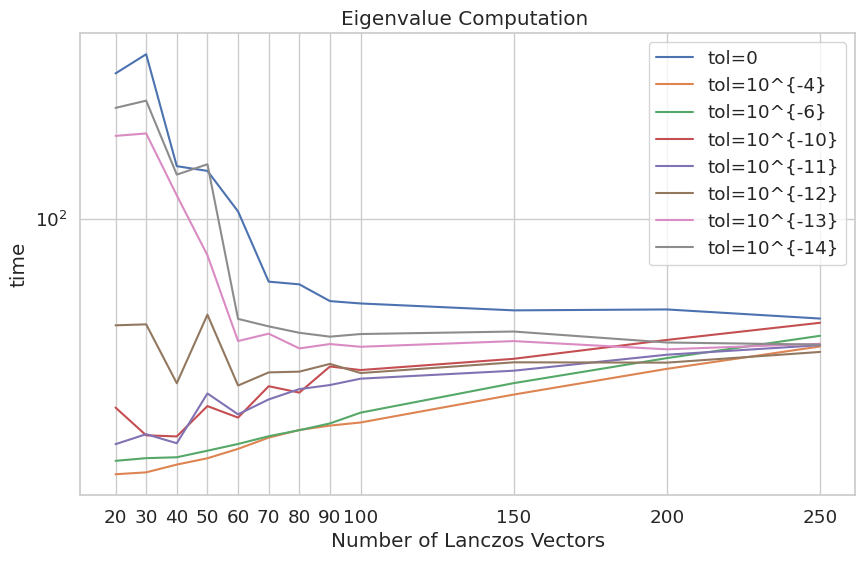

In [4]:
# read in data
df0 = pd.read_csv("profiles/tol0.0.csv",index_col=0)
df4 = pd.read_csv("profiles/tol0.0001.csv",index_col=0)
df6 = pd.read_csv("profiles/tol1e-06.csv",index_col=0)
df10 = pd.read_csv("profiles/tol1e-10.csv",index_col=0)
df11 = pd.read_csv("profiles/tol1e-11.csv",index_col=0)
df12 = pd.read_csv("profiles/tol1e-12.csv",index_col=0)
df13 = pd.read_csv("profiles/tol1e-13.csv",index_col=0)
df14 = pd.read_csv("profiles/tol1e-14.csv",index_col=0)

# function for plotting the data as a line graph
def make_plot(col,xlim=None, ylim=None):
    plt.figure(figsize=(10,6))

    ax = sns.lineplot(df0,x="min_ncv",y=col,label="tol=0")
    ax = sns.lineplot(df4,x="min_ncv",y=col,label="tol=10^{-4}")
    ax = sns.lineplot(df6,x="min_ncv",y=col,label="tol=10^{-6}")
    ax = sns.lineplot(df10,x="min_ncv",y=col,label="tol=10^{-10}")
    ax = sns.lineplot(df11,x="min_ncv",y=col,label="tol=10^{-11}")
    ax = sns.lineplot(df12,x="min_ncv",y=col,label="tol=10^{-12}")
    ax = sns.lineplot(df13,x="min_ncv",y=col,label="tol=10^{-13}")
    ax = sns.lineplot(df14,x="min_ncv",y=col,label="tol=10^{-14}")
    plt.xlabel("Number of Lanczos Vectors")
    plt.ylabel(f"{col}")
    plt.xticks([20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250])
    plt.title(f"Eigenvalue Computation ")
    plt.yscale("log")
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.legend()

    plt.show()
make_plot(col="time")

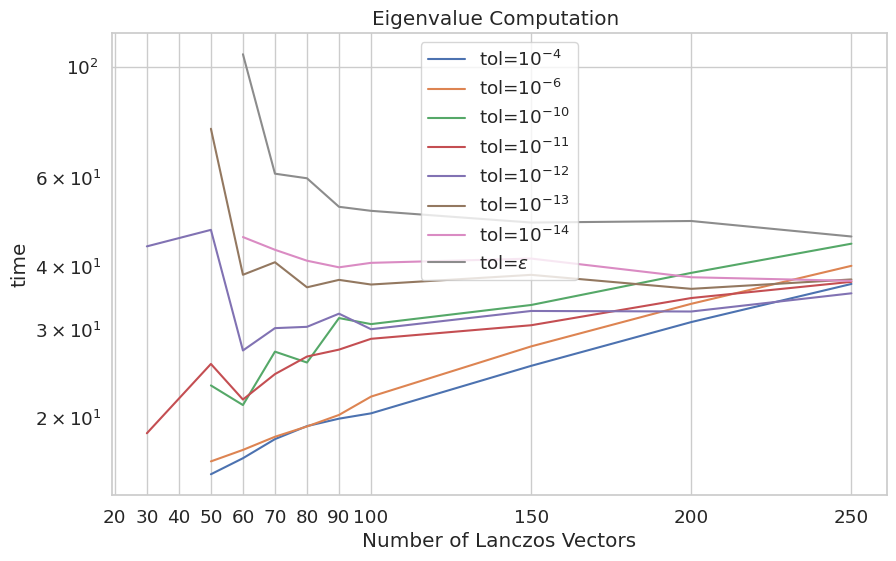

In [5]:
# goal: Identify fastest combination of tolerance and lanczos vectors without errors

# do the same line plot, but now restricted to only data without erros

dfs = [df4, df6, df10, df11, df12, df13, df14,df0]
df_labels = [r'$10^{-4}$',r'$10^{-6}$',r'$10^{-10}$',r'$10^{-11}$',r'$10^{-12}$',r'$10^{-13}$',r'$10^{-14}$',r'$\epsilon$']


plt.figure(figsize=(10,6))
col = "time"
for idx, df in enumerate(dfs):
    good_data = df[(df["failures"] == 0) & (df["max_error"] < 1e-5)]
    ax = sns.lineplot(good_data,x="min_ncv",y=col,label=f"tol={df_labels[idx]}")
plt.xlabel("Number of Lanczos Vectors")
plt.ylabel(f"{col}")
plt.xticks([20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250])
plt.title(f"Eigenvalue Computation ")
plt.yscale("log")
plt.legend()

plt.show()
    

In [6]:
# transform and combine all of the data
# columns = min_ncv
# rows = tol
# entries = time else np.nan if failures > 0 or max_error > 10^-5

def df_transform(df,label):
    df_t = df.copy()
    # print(df_t)
    df_t.loc[(df_t["max_error"] > 1e-5) | (df_t["failures"] > 0),"time"] = np.nan

    df_t.drop(columns=["max_error","failures"], inplace=True)
    df_t.set_index("min_ncv",inplace=True)
    df_t = df_t.T
    df_t = df_t.rename(index={"time":label})
    return df_t


dfs_t = [df_transform(df,df_labels[idx]) for idx, df in enumerate(dfs)]
df_t = pd.concat(dfs_t)
print(df_t)

min_ncv     20         30   40         50          60         70         80   \
$10^{-4}$   NaN        NaN  NaN  15.451162   16.628692  18.150276  19.264919   
$10^{-6}$   NaN        NaN  NaN  16.389807   17.274324  18.347283  19.234244   
$10^{-10}$  NaN        NaN  NaN  23.212540   21.217850  27.100684  25.782122   
$10^{-11}$  NaN  18.643415  NaN  25.615199   21.761213  24.451319  26.499223   
$10^{-12}$  NaN  43.904543  NaN  47.354890   27.247408  30.183529  30.364776   
$10^{-13}$  NaN        NaN  NaN  75.268515   38.544990  40.823489  36.392975   
$10^{-14}$  NaN        NaN  NaN        NaN   45.818397  43.220661  41.111400   
$\epsilon$  NaN        NaN  NaN        NaN  105.895448  61.258118  59.982025   

min_ncv           90         100        150        200        250  
$10^{-4}$   19.933985  20.425745  25.393314  31.035312  36.955656  
$10^{-6}$   20.277204  22.055040  27.760970  33.744659  40.157470  
$10^{-10}$  31.608502  30.745728  33.561977  38.884409  44.447354  
$10^{-1

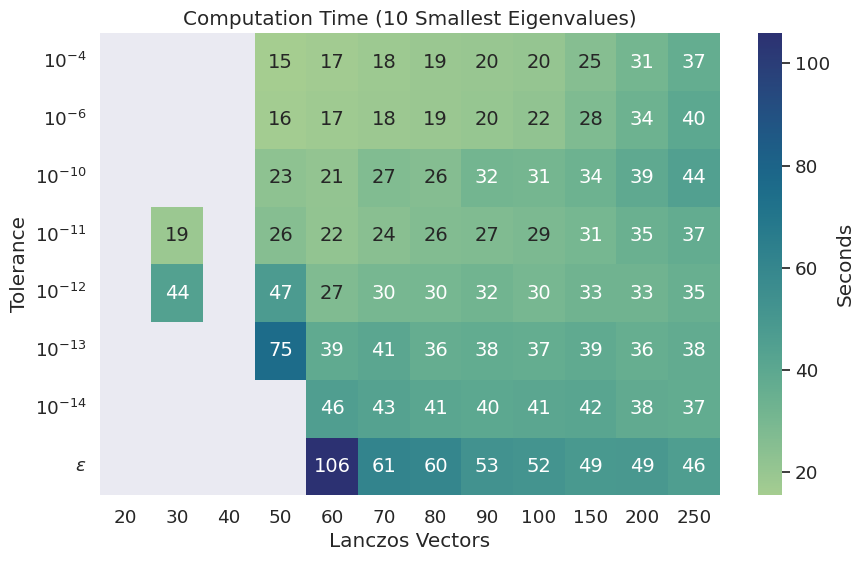

In [9]:
# plot as heatmap
plt.figure(figsize=(10,6))
sns.set_theme(style="dark",font_scale=1.2,rc=rc) 
ax = sns.heatmap(df_t,cmap="crest",mask=df_t.isnull(),cbar_kws={'label': 'Seconds'}, annot=True,fmt=".0f")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.title("Computation Time (10 Smallest Eigenvalues)")
plt.ylabel("Tolerance")
plt.xlabel("Lanczos Vectors")
plt.savefig("lanczos_vec_time.png",dpi=600,bbox_inches="tight")
plt.show()